# Hlavní Prework Projekt: Příprava dat pro model ve strojovém učení (Cancer Dataset)

Tento sešit představuje kompletní praktickou implementaci kroků předzpracování a přípravy dat (**Data Preparation Pipeline**) před samotným trénováním modelů strojového učení.

### Klíčové fáze pipeline:
1. **Načtení a prvotní inspekce dat** (`pd.read_csv`, `.head()`, `.info()`, `.isnull()`)
2. **Odstranění redundantních proměnných** (`id`, `Unnamed: 32`)
3. **Zpracování chybějících hodnot** (filtrace chybějících řádků přes `.dropna()` vs. imputace přes `SimpleImputer`)
4. **Detekce a odstranění duplicit** (`.duplicated()`)
5. **Kódování kategorických proměnných** (normalizace velikosti písmen, `pd.get_dummies()`, `OneHotEncoder`)
6. **Analýza numerických vlastností a vizualizace** (`.describe()`, korelační heatmapa, rozdělení proměnných)
7. **Škálování a normalizace příznaků** (`MinMaxScaler` ze Scikit-learn vs. vlastní funkce)
8. **Rozdělení dat na podmnožiny** (trénovací, validační a testovací sada pomocí `train_test_split`)

## 1. Načtení datasetu a prvotní inspekce

Dataset obsahuje parametry diagnostiky nádorových buněk (např. průměrný poloměr `radius_mean`, texturu `texture_mean`, hladkost `smoothness_mean`, atd.). Cílem je předpovědět, zda je nádor nezhoubný (**B** - Benign) nebo zhoubný (**M** - Malignant).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Načtení datasetu
data_path = os.path.join("data", "cancer_data_course.csv")
cancer_df = pd.read_csv(data_path)

print(f"Rozměry datasetu: {cancer_df.shape[0]} řádků, {cancer_df.shape[1]} sloupců")
cancer_df.head(10)

Rozměry datasetu: 569 řádků, 34 sloupců


,Unnamed: 0,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [2]:
# Zobrazení datových typů a nenulových hodnot
cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               569 non-null    int64  
 1   id                       569 non-null    int64  
 2   diagnosis                569 non-null    str    
 3   radius_mean              567 non-null    float64
 4   texture_mean             562 non-null    float64
 5   perimeter_mean           568 non-null    float64
 6   area_mean                564 non-null    float64
 7   smoothness_mean          563 non-null    float64
 8   compactness_mean         568 non-null    float64
 9   concavity_mean           566 non-null    float64
 10  concave points_mean      567 non-null    float64
 11  symmetry_mean            564 non-null    float64
 12  fractal_dimension_mean   564 non-null    float64
 13  radius_se                565 non-null    float64
 14  texture_se               567 non-null

## 2. Odstranění redundantních proměnných

Sloupec `id` je pouze ordinální identifikátor vyšetření a nenese žádnou prediktivní hodnotu pro klasifikaci. Sloupec `Unnamed: 32` (a případně exportní `Unnamed: 0`) vznikl chybou při exportu a obsahuje výhradně prázdné hodnoty.

In [3]:
# Identifikace a odstranění zbytečných sloupců
redundant_cols = [c for c in ["id", "Unnamed: 32", "Unnamed: 0"] if c in cancer_df.columns]
cancer_df = cancer_df.drop(columns=redundant_cols)

print(f"Odstraněno: {redundant_cols}")
print(f"Nový tvar tabulky: {cancer_df.shape}")

Odstraněno: ['id', 'Unnamed: 32', 'Unnamed: 0']
Nový tvar tabulky: (569, 31)


## 3. Zpracování chybějících hodnot (Missing Values)

Nejprve spočítáme procentuální zastoupení chybějících hodnot v jednotlivých sloupcích.

In [4]:
# Procentuální podíl chybějících hodnot ve sloupcích
missing_pct = (cancer_df.isnull().sum() / len(cancer_df)) * 100
missing_summary = pd.DataFrame({
    "Chybějící hodnoty": cancer_df.isnull().sum(),
    "Podíl (%)": missing_pct.round(2)
})
missing_summary[missing_summary["Chybějící hodnoty"] > 0]

,Chybějící hodnoty,Podíl (%)
radius_mean,2,0.35
texture_mean,7,1.23
perimeter_mean,1,0.18
area_mean,5,0.88
smoothness_mean,6,1.05
compactness_mean,1,0.18
concavity_mean,3,0.53
concave points_mean,2,0.35
symmetry_mean,5,0.88
fractal_dimension_mean,5,0.88


### Varianta A: Odstranění řádků s chybějícími hodnotami (`dropna`)
Protože je podíl chybějících hodnot velmi malý (kolem 0.2 - 1.2 %), můžeme tyto řádky bezpečně zahodit. Po tomto kroku nám zůstane přesně **549 řádků**.

In [5]:
# Odstranění řádků s alespoň jednou chybějící hodnotou a reset indexu
cancer_df = cancer_df.dropna(axis=0).reset_index(drop=True)
print(f"Počet řádků po dropna: {len(cancer_df)}")

Počet řádků po dropna: 549


### Varianta B (Alternativa): Imputace pomocí `SimpleImputer` ze Scikit-learn
Pokud bychom řádky nechtěli mazat, můžeme prázdná místa doplnit průměrem (`mean`), mediánem (`median`) či nejčastější hodnotou.

In [6]:
from sklearn.impute import SimpleImputer

# Ukázka imputace průměrem pro numerické sloupce
imputer = SimpleImputer(strategy="mean")
numeric_cols = cancer_df.select_dtypes(include=[np.number]).columns
imputed_array = imputer.fit_transform(cancer_df[numeric_cols])
print(f"Imputováno {imputed_array.shape[1]} numerických vlastností.")

Imputováno 30 numerických vlastností.


## 4. Detekce a odstranění duplicit

Metodou `.duplicated().sum()` ověříme přítomnost duplicitních řádků.

In [7]:
num_duplicates = cancer_df.duplicated().sum()
print(f"Počet duplicitních řádků v datasetu: {num_duplicates}")

if num_duplicates > 0:
    cancer_df = cancer_df.drop_duplicates().reset_index(drop=True)

Počet duplicitních řádků v datasetu: 0


## 5. Kódování kategorických proměnných (`diagnosis`)

Zkontrolujeme hodnoty v proměnné `diagnosis`. Najdeme zde hodnoty `B` (Benign), `M` (Malignant) a také malá písmena `b` vzniklá překlepem při zadávání dat.

In [8]:
print("Počet unikátních hodnot:", cancer_df["diagnosis"].nunique())
print("\nČetnosti jednotlivých hodnot před opravou:")
print(cancer_df["diagnosis"].value_counts())

# Normalizace překlepu: převod 'b' na 'B'
cancer_df["diagnosis"] = cancer_df["diagnosis"].replace("b", "B")

print("\nČetnosti po opravě:")
print(cancer_df["diagnosis"].value_counts())

Počet unikátních hodnot: 3

Četnosti jednotlivých hodnot před opravou:
diagnosis
B    344
M    202
b      3
Name: count, dtype: int64

Četnosti po opravě:
diagnosis
B    347
M    202
Name: count, dtype: int64


### Kódování pomocí `pd.get_dummies(..., drop_first=True)` [Doporučeno]

Použití `drop_first=True` vytvoří jediný sloupec `diagnosis_M`:
- `1` = Malignant (zhoubný nádor)
- `0` = Benign (nezhoubný nádor)

In [9]:
cancer_encoded_df = pd.get_dummies(cancer_df, columns=["diagnosis"], drop_first=True, dtype=int)
target_col = [c for c in cancer_encoded_df.columns if "diagnosis" in c][0]
print(f"Cílová zakódovaná proměnná: '{target_col}'")
cancer_encoded_df[[target_col]].value_counts()

Cílová zakódovaná proměnná: 'diagnosis_M'


diagnosis_M
0              347
1              202
Name: count, dtype: int64

## 6. Analýza vztahů v numerických datech a vizualizace

Prozkoumáme základní statistiky (průměr, rozptyl, minima, maxima), abychom odhalili rozdíly v měřítkách jednotlivých proměnných.

In [10]:
# Přehled základních statistik
cancer_encoded_df.describe().T[["mean", "std", "min", "50%", "max"]].head(10)

,mean,std,min,50%,max
radius_mean,14.127362,3.519305,6.98100,13.37000,28.11000
texture_mean,19.270638,4.332922,9.71000,18.83000,39.28000
perimeter_mean,91.961220,24.257656,43.79000,86.34000,188.50000
area_mean,654.761931,351.611898,143.50000,551.10000,2501.00000
smoothness_mean,0.096335,0.014088,0.05263,0.09592,0.16340
compactness_mean,0.104206,0.052841,0.01938,0.09242,0.34540
concavity_mean,0.088678,0.079543,0.00000,0.06155,0.42680
concave points_mean,0.048895,0.038680,0.00000,0.03350,0.20120
symmetry_mean,0.181071,0.027548,0.10600,0.17930,0.30400
fractal_dimension_mean,0.062794,0.007098,0.04996,0.06149,0.09744


### Korelační matice a vizualizace pomocí Seaborn heatmapy

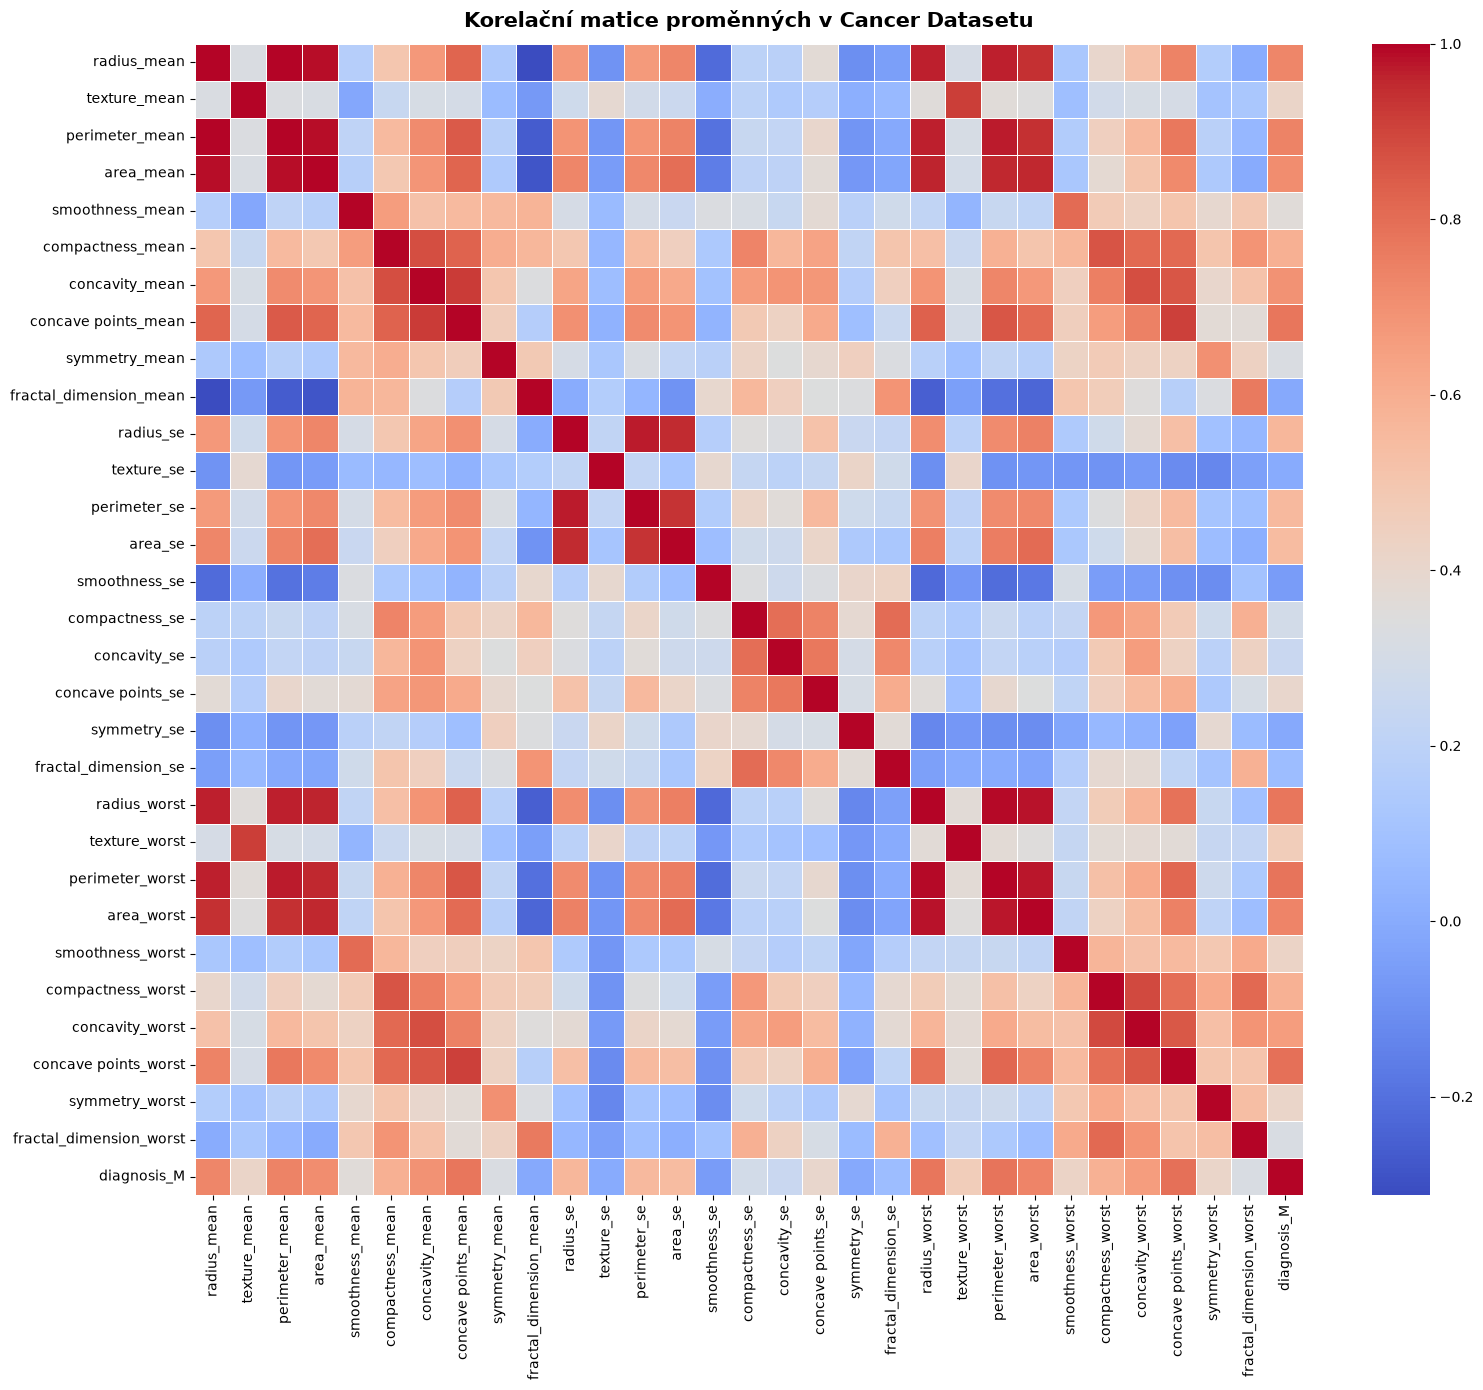

In [11]:
corr_matrix = cancer_encoded_df.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Korelační matice proměnných v Cancer Datasetu", fontsize=15, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### Rozdělení hodnot vybrané proměnné (`radius_mean`)
Hodnoty v mnoha sloupcích neodpovídají normálnímu Gaussovu rozdělení, proto pro sjednocení měřítek použijeme **Min-Max normalizaci** namísto standardizace (Z-score).

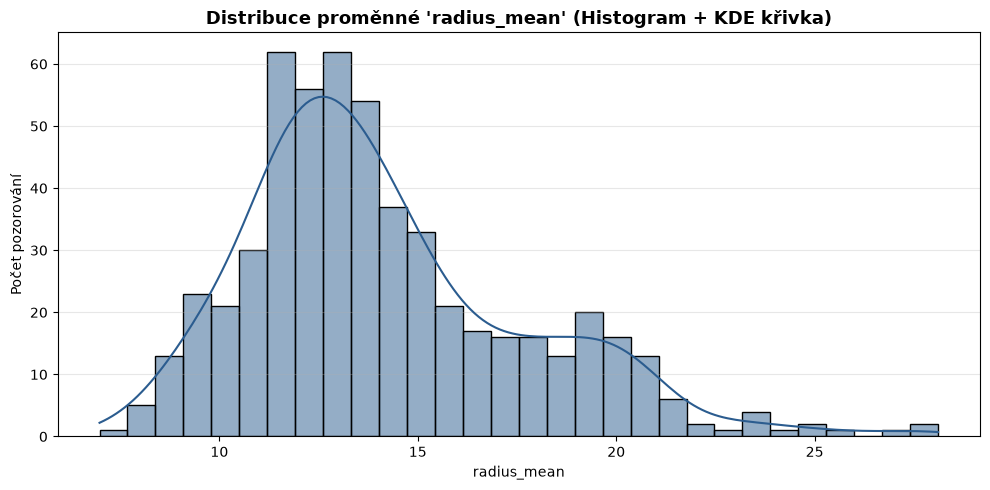

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(cancer_encoded_df["radius_mean"], kde=True, color="#2b5c8f", bins=30)
plt.title("Distribuce proměnné 'radius_mean' (Histogram + KDE křivka)", fontsize=13, fontweight="bold")
plt.xlabel("radius_mean")
plt.ylabel("Počet pozorování")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Normalizace dat (MinMaxScaler)

Škálováním převedeme všechny numerické sloupce do jednotného rozsahu $[0, 1]$:
$$
x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cancer_normalized = scaler.fit_transform(cancer_encoded_df)
cancer_normalized_df = pd.DataFrame(data=cancer_normalized, columns=scaler.get_feature_names_out())

print("Normalizovaný dataset:")
cancer_normalized_df.head()

Normalizovaný dataset:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864,1.0
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878,1.0
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433,1.0
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,1.0
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595,1.0


## 8. Rozdělení dat na trénovací, validační a testovací množinu

Nejprve oddělíme matici příznaků $X$ od vektoru cílové proměnné $y$ (`diagnosis_M`).

In [14]:
X = cancer_normalized_df.drop(columns=[target_col])
y = cancer_normalized_df[target_col]

print(f"Tvar matice příznaků X: {X.shape}")
print(f"Tvar cílové proměnné y: {y.shape}")

Tvar matice příznaků X: (549, 30)
Tvar cílové proměnné y: (549,)


### A) 2-cestné rozdělení (70 % trénovací / 30 % testovací sada)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("2-cestný split:")
print(f"- X_train: {X_train.shape} ({len(X_train)/len(X)*100:.1f} %)")
print(f"- X_test:  {X_test.shape} ({len(X_test)/len(X)*100:.1f} %)")

2-cestný split:
- X_train: (384, 30) (69.9 %)
- X_test:  (165, 30) (30.1 %)


### B) 3-cestné rozdělení (70 % trénovací / 15 % validační / 15 % testovací sada)

Provedeme dodatečné rozdělení testovací sady v poměru 50:50 na validační a finální testovací sadu.

In [16]:
X_test_final, X_valid, y_test_final, y_valid = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42
)

print("3-cestný split:")
print(f"- X_train:      {X_train.shape} (70 %)")
print(f"- X_valid:      {X_valid.shape} (15 %)")
print(f"- X_test_final: {X_test_final.shape} (15 %)")

3-cestný split:
- X_train:      (384, 30) (70 %)
- X_valid:      (83, 30) (15 %)
- X_test_final: (82, 30) (15 %)


## Shrnutí
V tomto projektu jsme úspěšně realizovali celý proces přípravy dat:
- Odstranění zbytečných a prázdných sloupců.
- Ošetření chybějících hodnot a normalizaci textových chyb (`b` -> `B`).
- Zakódování cílové proměnné na binární tvar pomocí `pd.get_dummies`.
- Prozkoumání korelací a distribucí.
- Min-Max škálování do intervalu $[0, 1]$.
- Rozdělení do trénovací, validační a testovací sady připravené pro trénování modelů strojového učení.